In [83]:
#imports
import sys
import os

# Adds the parent directory to the search path
parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
    
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import xtrack as xt


In [84]:
#read in file
df = pd.read_csv('PositronBeam_2p86GeV/Beam_3GHzOption_2.86GeV_20260421.dat', sep=r'\s+')
print(list(df.columns))

['x[mm]', 'xp[mrad]', 'y[mm]', 'yp[mrad]', 't[mm/c]', 'p[MeV/c]', 'ID']


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def CalcEmittanceManual(df, position, angle):
    pos = df[position].values
    ang = df[angle].values

    x_c = pos - np.mean(pos)
    xp_c = ang - np.mean(ang)

    x2_mean = np.mean(x_c**2)
    xp2_mean = np.mean(xp_c**2)
    xxp_mean = np.mean(x_c * xp_c)
    
    emittance = np.sqrt(x2_mean * xp2_mean - xxp_mean**2)
    return emittance

def CalcEmittanceAuto(df, position, angle):
    pos = df[position].values
    ang = df[angle].values
    
    cov = np.cov(pos, ang, ddof=0) 
    emittance = np.sqrt(np.linalg.det(cov))
    return emittance


def NormalisedEmittance(emittance, E_total_mev):
    # Electron/Positron rest mass in MeV
    m0 = 0.510998 
    
    gamma_rel = E_total_mev / m0
    beta_rel = np.sqrt(1 - 1/gamma_rel**2)
    
    n_emittance = beta_rel * gamma_rel * emittance
    return n_emittance

def get_twiss(df, position, angle, p_col='p[MeV/c]', p0_mev=2860.0):
    pos = df[position].values
    ang = df[angle].values
    
    # Calculate emittance 
    eps = CalcEmittanceAuto(df, position, angle)
    
    cov_matrix = np.cov(pos, ang, ddof=0)
    
    beta = cov_matrix[0, 0] / eps
    alpha = -cov_matrix[0, 1] / eps
    gamma = (1 + alpha**2) / beta
    
    # Dispersion calculation
    delta = (df[p_col].values - p0_mev) / p0_mev
    dispersion_x = np.cov(pos, delta, ddof=0)[0, 1] / np.var(delta)
    disp_prime_x = np.cov(ang, delta, ddof=0)[0, 1] / np.var(delta)
    
    return alpha, beta, gamma, dispersion_x, disp_prime_x



def plot_twiss_ellipse(beta, alpha, beta2, alpha2, emittance):
    gamma = (1 + alpha**2) / beta
    theta = np.linspace(0, 2*np.pi, 100)
    
    x1 = np.sqrt(emittance * beta) * np.cos(theta)
    xp1 = -np.sqrt(emittance / beta) * (alpha * np.cos(theta) - np.sin(theta))
    x2 = np.sqrt(emittance * beta2) * np.cos(theta)
    xp2 = -np.sqrt(emittance / beta2) * (alpha2 * np.cos(theta) - np.sin(theta))
    
    plt.figure(figsize=(6,6))
    plt.plot(x1, xp1, label=f'Particle distribution: α={alpha:.2f}, β={beta:.2f} m',color='blue')
    plt.plot(x2, xp2, label=f'Initial ring parameters: α={alpha2:.2f}, β={beta2:.2f} m',color='red')
    plt.axhline(0, color='black', lw=0.5, ls='--')
    plt.axvline(0, color='black', lw=0.5, ls='--')
    plt.xlabel('Position x [mm]')
    plt.ylabel("Divergence x' [mrad]")
    plt.title('Phase Space Twiss Ellipse (RMS)')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.axis('equal')
    plt.show()

def plot_twiss_ellipse_normalised(beta_l,alpha_l,beta_r, alpha_r,emittance):

    phi=np.linspace(0,2*np.pi,500)

    x = np.sqrt(emittance * beta_l) * np.cos(phi)
    xp = - (np.sqrt(emittance / beta_l)) * (alpha_l * np.cos(phi) + np.sin(phi))


    zeta=(1/(np.sqrt(beta_l)))*x
    zeta_prime=np.sqrt(beta_l)*xp+(alpha_l/np.sqrt(beta_l))*x

    zeta_r=(1/(np.sqrt(beta_r)))*x
    zeta_prime_r=np.sqrt(beta_r)*xp+(alpha_r/np.sqrt(beta_r))*x

    plt.figure(figsize=(6, 6))
    plt.plot(zeta, zeta_prime, color='blue', label='Particle distribution')
    plt.plot(zeta_r, zeta_prime_r, color='red', label='Initial ring parameters')
    plt.title(f"Normalized Phase Space ($\epsilon$={emittance})")
    plt.xlabel(r"$\zeta$")
    plt.ylabel(r"$\zeta'$")
    plt.axis('equal') 
    plt.grid(True, linestyle=':')
    plt.legend()
    plt.show()



def plot_twiss_with_particles(df, pos_col, ang_col, alpha, beta, emittance):
    gamma = (1 + alpha**2) / beta
    
    plt.figure(figsize=(7, 7))
    ax = plt.gca()
    
    ax.scatter(df[pos_col], df[ang_col], s=1, alpha=0.3, label='Particles')
    
    theta = np.linspace(0, 2*np.pi, 200)
    x = np.sqrt(emittance * beta) * np.cos(theta)
    xp = -np.sqrt(emittance / beta) * (alpha * np.cos(theta) - np.sin(theta))
    
    ax.plot(x, xp, color='red', lw=2, label=f'RMS Ellipse (ε={emittance:.2f})')
    
    
    ax.axhline(0, color='black', lw=1, ls='--')
    ax.axvline(0, color='black', lw=1, ls='--')
    ax.set_xlabel(pos_col)
    ax.set_ylabel(ang_col)
    ax.set_title(f'Phase Space: {pos_col} vs {ang_col}')
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)
    
    plt.show()


<>:99: SyntaxWarning: invalid escape sequence '\e'
<>:99: SyntaxWarning: invalid escape sequence '\e'
/tmp/mwatson/ipykernel_1128582/3648220879.py:99: SyntaxWarning: invalid escape sequence '\e'
  plt.title(f"Normalized Phase Space ($\epsilon$={emittance})")


In [86]:

emittance_x=CalcEmittanceAuto(df, 'x[mm]', 'xp[mrad]')
m_emittance_x=CalcEmittanceManual(df, 'x[mm]', 'xp[mrad]')
#nemitt_x=NormalisedEmittance(df['x[mm]'],df['xp[mrad]'],emittance_x)
#print(nemitt_x)
print(f'Horizontal geometric emittance:{emittance_x} um, {m_emittance_x}um' )

emittance_y=CalcEmittanceAuto(df, 'y[mm]', 'yp[mrad]')
m_emittance_y=CalcEmittanceManual(df, 'y[mm]', 'yp[mrad]')
print(f'Vertical geometric emittance:{emittance_y} um, {m_emittance_y}um' )
#nemitt_y=NormalisedEmittance(df['x[mm]'],df['xp[mrad]'],emittance_y)
#print(nemitt_y)

# Correct way to call it:
ax, bx, gx, dx, ddx = get_twiss(df, 'x[mm]', 'xp[mrad]')
# Correct way to call it:
ay, by, gy, dy, ddy = get_twiss(df, 'y[mm]', 'yp[mrad]')
print(f"Beam Twiss: alpha_x={ax:.3f}, beta_x={bx:.3f} m, dx={dx:.3f} m,ddx={ddx:.3f} m")
print(f"Beam Twiss: alpha_y={ay:.3f}, beta_y={by:.3f} m, dy={dx:.3f} m,ddy={ddx:.3f} m")

p_array=df['p[MeV/c]']

p_avg = np.mean(p_array)
rms_spread = np.std(p_array)  
relative_spread = (rms_spread / p_avg) *100

print(f"RMS Momentum Spread: {relative_spread} %")


Horizontal geometric emittance:1.354177116369456 um, 1.3541771163694545um
Vertical geometric emittance:1.420755089827341 um, 1.4207550898273411um
Beam Twiss: alpha_x=-2.176, beta_x=6.694 m, dx=0.617 m,ddx=0.165 m
Beam Twiss: alpha_y=0.644, beta_y=1.648 m, dy=0.617 m,ddy=0.165 m
RMS Momentum Spread: 6.477741044455877 %


Text(0.5, 1.0, 'Transverse Real-Space Profile')

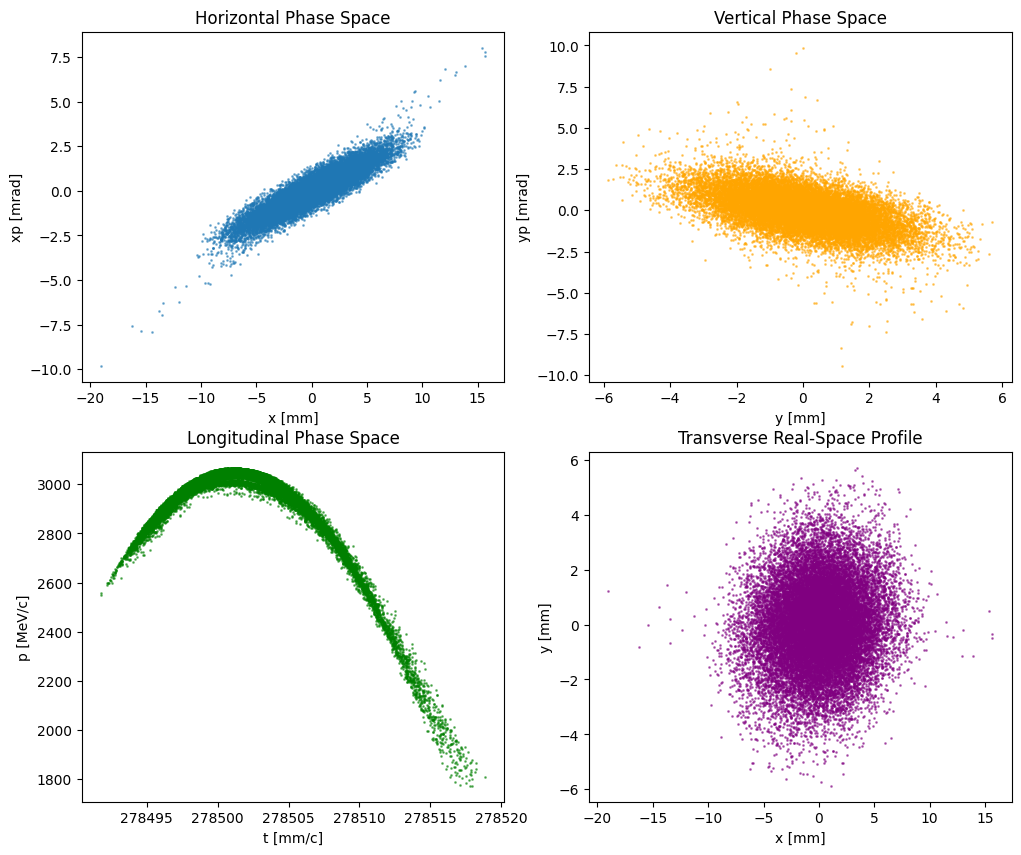

In [87]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

#Horizontal Phase Space
axes[0, 0].scatter(df['x[mm]'], df['xp[mrad]'], s=1, alpha=0.5)
axes[0, 0].set_xlabel('x [mm]')
axes[0, 0].set_ylabel('xp [mrad]')
axes[0, 0].set_title('Horizontal Phase Space')

#Vertical Phase Space
axes[0, 1].scatter(df['y[mm]'], df['yp[mrad]'], s=1, alpha=0.5, color='orange')
axes[0, 1].set_xlabel('y [mm]')
axes[0, 1].set_ylabel('yp [mrad]')
axes[0, 1].set_title('Vertical Phase Space')

#Longitudinal Phase Space
main_bunch = df[df['t[mm/c]'] < 278540]
axes[1, 0].scatter(main_bunch['t[mm/c]'], main_bunch['p[MeV/c]'], s=1, alpha=0.5, color='green')
axes[1, 0].set_xlabel('t [mm/c]')
axes[1, 0].set_ylabel('p [MeV/c]')
axes[1, 0].set_title('Longitudinal Phase Space')

#Transverse Profile
axes[1, 1].scatter(df['x[mm]'], df['y[mm]'], s=1, alpha=0.5, color='purple')
axes[1, 1].set_xlabel('x [mm]')
axes[1, 1].set_ylabel('y [mm]')
axes[1, 1].set_title('Transverse Real-Space Profile')



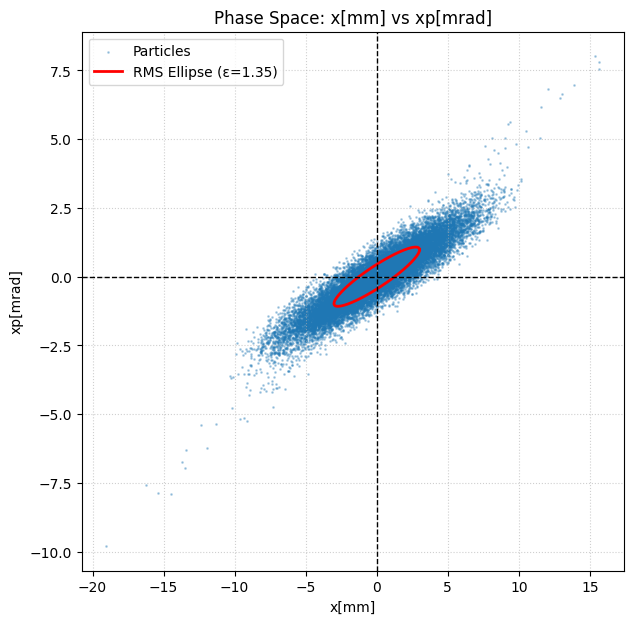

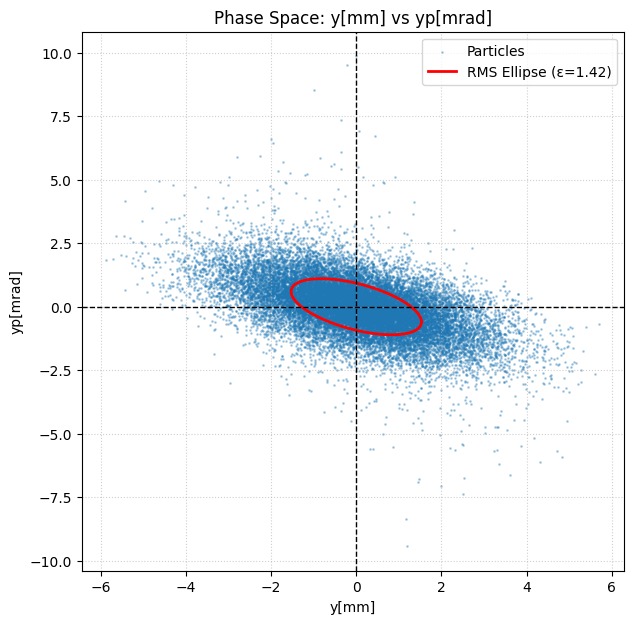

In [88]:

plot_twiss_with_particles(df, 'x[mm]', 'xp[mrad]', ax, bx, emittance_x)
plot_twiss_with_particles(df, 'y[mm]', 'yp[mrad]', ay, by, emittance_y)

In [89]:

# Save twiss results
beam_results = {
    "x": {
        "alpha": float(ax),
        "beta": float(bx),
        "gamma": float(gx),
        "dispersion": float(dx),
        "dispersion_prime": float(ddx),
        "emittance_geo": float(emittance_x)
    },
    "y": {
        "alpha": float(ay),
        "beta": float(by),
        "gamma": float(gy),
        "dispersion": float(dy),
        "dispersion_prime": float(ddy),
        "emittance_geo": float(emittance_y)
    },
    "metadata": {
        "particle_type": "positron",
        "design_energy_mev": 2860.0,
        "n_particles": len(df['ID'])
    }
}

with open('TwissResults.json', 'w') as f:
    json.dump(beam_results, f, indent=4)


Loading line from dict:   0%|          | 0/5296 [00:00<?, ?it/s]

Done loading line from dict.           
Done loading line from dict.           
Done loading line from dict.           
ColView: name s x px y py zeta delta ptau W_matrix kin_px kin_py kin_ps kin_xprime kin_yprime env_name betx bety alfx alfy gamx gamy dx dpx dy dpy dx_zeta dpx_zeta dy_zeta dpy_zeta betx1 bety1 betx2 bety2 alfx1 alfy1 alfx2 alfy2 gamx1 gamy1 gamx2 gamy2 mux muy muzeta nux nuy nuzeta phix phiy phizeta c_minus_re c_minus_im c_r1 c_r2 c_phi1 c_phi2 dmux dmuy dzeta bx_chrom by_chrom ax_chrom ay_chrom wx_chrom wy_chrom ddx ddpx ddy ddpy


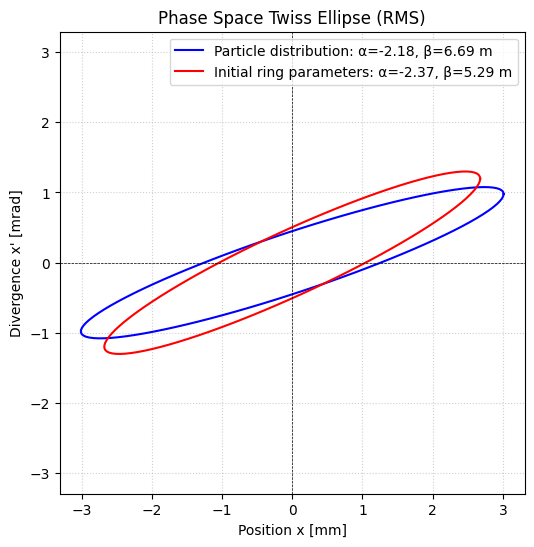

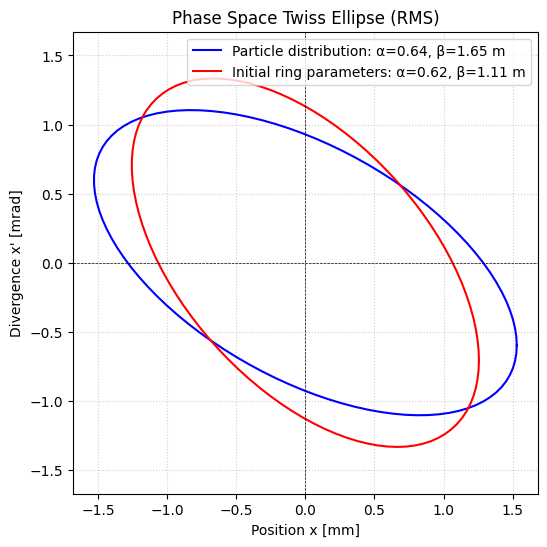

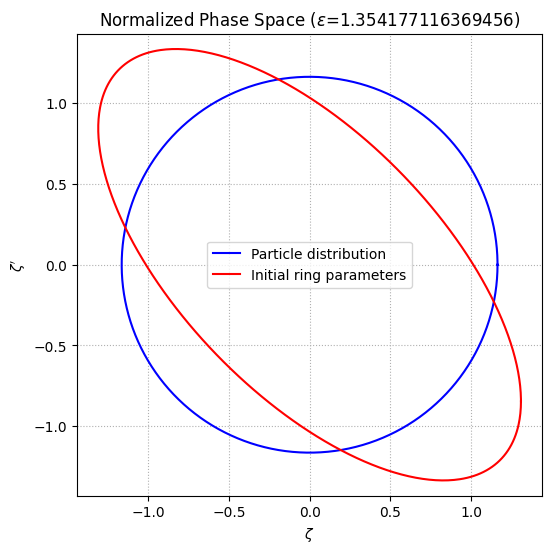

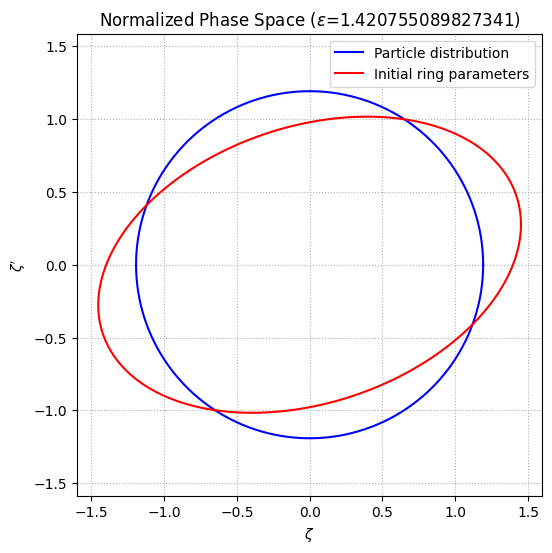

In [ ]:
ring=xt.Line.from_json('current_ring.json')

#ring twiss values
ring_tw=ring.twiss6d()
print(ring_tw.cols)
# Initial values
initial_twiss = ring_tw.rows[0]

#Horizontal
betx0 = initial_twiss['betx'][0]
alfx0 = initial_twiss['alfx'][0]
dx0   = initial_twiss['dx'][0]
x     = initial_twiss['x'][0]
xp    = initial_twiss['px'][0]


#Vertical
bety0 = initial_twiss['bety'][0]
alfy0 = initial_twiss['alfy'][0]
dy0   = initial_twiss['dy'][0]
y     = initial_twiss['y'][0]
yp    = initial_twiss['py'][0]

delta= initial_twiss['delta'][0]

plot_twiss_ellipse(bx,ax,betx0, alfx0, emittance_x)
plot_twiss_ellipse(by,ay,bety0, alfy0, emittance_y)

plot_twiss_ellipse_normalised(bx,ax,betx0, alfx0, emittance_x)
plot_twiss_ellipse_normalised(by,ay,bety0, alfy0, emittance_y)
